# TP 2: Réseau de neurone MLP - classification avec Scikit-Learn

**MLP = Multi-Layer Perceptron**

Exemple tiré du livre Machine Learning with Scikit-Learn and PyTorch, Aurélien Géron

## Import des librairies

In [18]:
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

## Chargement des données

In [2]:
fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)
targets = fashion_mnist.target.astype(int)

## Séparation des données en jeux d'entraînement et de test

In [5]:
X_train, y_train = fashion_mnist.data[:60_000], targets[:60_000]
X_test, y_test = fashion_mnist.data[60_000:], targets[60_000:]

## Visualisation d'une image

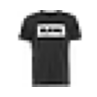

In [14]:
# Sélectionner une image
image_nb = 1
X_sample = X_train[image_nb].reshape(28, 28)
# Construction de l'image
plt.figure(figsize=(1,1))
plt.imshow(X_sample, cmap="binary")
plt.axis('off')
plt.show()

## Labellisation des images

Par défaut, les labels sont des chiffres, ce qui n'est pas très explicite. Il est préférable d'y affecter des noms de vêtement.

In [15]:
class_names = ["T-shirt/top", "Pantalon", "Pull", "Robe", "Manteau",
               "Sandales", "Chemisier", "Baskets", "Sac", "Boots"]
# Test immage
class_names[y_train[image_nb]]

'T-shirt/top'

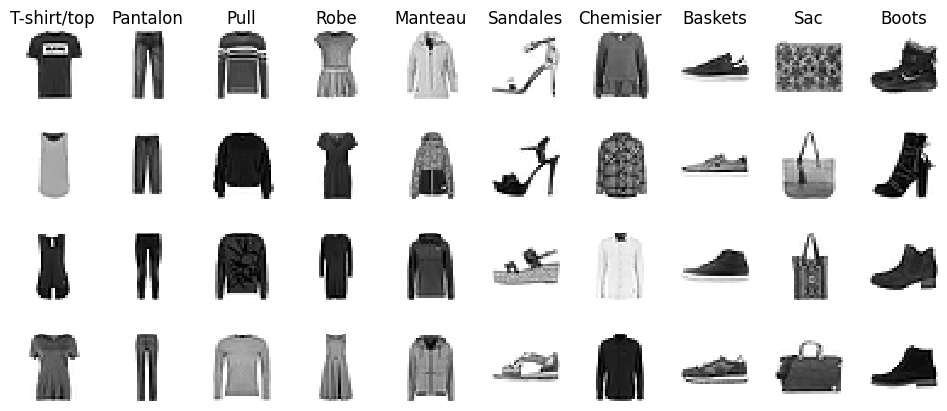

In [16]:
# extra code – this cell generates Figure 9–10
n_rows = 4
plt.figure(figsize=(12, n_rows * 1.2))
for row in range(n_rows):
    for class_index in range(10):
        X_img = X_train[y_train==class_index][row].reshape(28, 28)
        y_img = y_train[y_train==class_index][row]
        plt.subplot(n_rows, 10, 10 * row + class_index + 1)
        plt.imshow(X_img, cmap="binary", interpolation="nearest")
        plt.axis('off')
        if row == 0:
            plt.title(class_names[y_img])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

## Construction du réseau de neurone MLP pour tâche de classification

### Phase d'entraînement du modèle

In [19]:
# 2 couches profondes avec respectivement 200 puis 100 neurones
mlp_clf = MLPClassifier(hidden_layer_sizes=[200, 100], verbose=True,
                        early_stopping=True, random_state=42)
# Pipeline comprenant normalisation des données et entrainement du modèle
pipeline = make_pipeline(MinMaxScaler(), mlp_clf)
# Entraînement du modèle
pipeline.fit(X_train, y_train)

Iteration 1, loss = 0.57483807
Validation score: 0.849333
Iteration 2, loss = 0.39938584
Validation score: 0.856833
Iteration 3, loss = 0.35435272
Validation score: 0.869333
Iteration 4, loss = 0.32570927
Validation score: 0.863833
Iteration 5, loss = 0.30588352
Validation score: 0.874167
Iteration 6, loss = 0.29053832
Validation score: 0.874000
Iteration 7, loss = 0.27455976
Validation score: 0.879333
Iteration 8, loss = 0.26407281
Validation score: 0.878500
Iteration 9, loss = 0.25317835
Validation score: 0.882167
Iteration 10, loss = 0.24414312
Validation score: 0.892833
Iteration 11, loss = 0.23601645
Validation score: 0.890000
Iteration 12, loss = 0.23008384
Validation score: 0.887333
Iteration 13, loss = 0.22123722
Validation score: 0.885167
Iteration 14, loss = 0.21190658
Validation score: 0.879333
Iteration 15, loss = 0.20617121
Validation score: 0.892667
Iteration 16, loss = 0.19935674
Validation score: 0.891667
Iteration 17, loss = 0.19323595
Validation score: 0.891667
Iterat

In [20]:
# Meilleur score d'accuracy obtenu
mlp_clf.best_validation_score_

0.8973333333333333

### Phase de test du modèle sur de nouvelles données

In [22]:
# Prédiction du label de nouvelles images
X_new = X_test[:15]  # 15 nouvelles images
new_images = mlp_clf.predict(X_new)
new_images

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 8, 3, 4])

In [29]:
# Correspondance de ces labels
new_images_name = list()
for i in range(len(new_images)):
    name = class_names[new_images[i]]
    new_images_name.append(name)
new_images_name

['Boots',
 'Pull',
 'Pantalon',
 'Pantalon',
 'Chemisier',
 'Pantalon',
 'Manteau',
 'Chemisier',
 'Sandales',
 'Baskets',
 'Manteau',
 'Sandales',
 'Sac',
 'Robe',
 'Manteau']

Plutôt que d'identifer l'objet, il est possible de calculer la probabilité d'appartenance à chacune des classes. 

In [41]:
picture_nb = 9
y_proba = mlp_clf.predict_proba(X_test[picture_nb].reshape(1, -1))
y_proba

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]])